# Glacier Hydraulic Tremor

This notebook starts the identification of glacier hydraulic tremor at Eqalorutsit Kangilliit Sermiat (Qajuuttap Sermia). We have 3 seismometers installed: QJT01, QJT02, QJT03 with the components 'HHZ','HHN','HHE' for the vertical, north, and east component of each seismometer. The sampling frequency is 200Hz.

In [28]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
import datetime
import obspy
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client

## Read Seismic Data

In [5]:
# Read data
client = Client('</PATH/TO/DATA/>seismic/QJT_data/')

t_start = UTCDateTime('2023-08-15')
t_end = UTCDateTime('2023-08-30')
# only read 1 station and 1 channel for now
st_read = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
st_read.merge()

1 Trace(s) in Stream:
XH.QJT03..HHZ | 2023-08-15T00:00:00.000000Z - 2023-08-30T00:00:00.000000Z | 200.0 Hz, 259200001 samples

## Estimate glacier hydraulic tremor

In [8]:
# Select vertical component as a trace and calculate power spectrum 
tr = st_read.select(component='Z')[0]
data = tr.data
fs = tr.stats.sampling_rate #sampling rate
NFFT = int(fs*60*60)
Pxx, freqs, bins, _ = plt.specgram(data, 
                                    NFFT=NFFT, 
                                    Fs=fs)
plt.close()

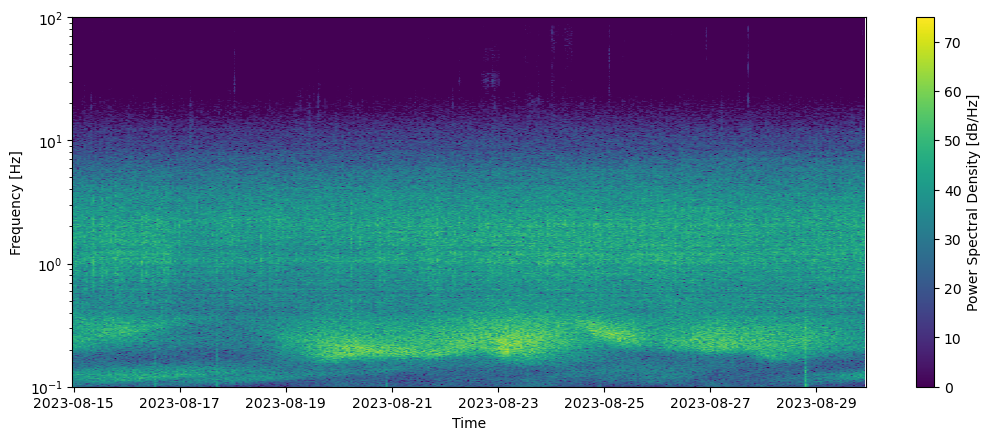

In [66]:
fig, ax = plt.subplots(figsize=(6.4*2,4.8))
dt_bins = bins[1]-bins[0]
t_bins = [tr.stats.starttime.datetime+datetime.timedelta(seconds=t-dt_bins) for t in bins]
im = ax.imshow(10*np.log10(Pxx), aspect='auto', origin='lower',
          extent=[t_bins[0], t_bins[-1], freqs[0], freqs[-1]],
                  vmin=0,vmax=75)
ax.set_ylim(0.1,100)
ax.set_yscale('log')
ax.set_ylabel('Frequency [Hz]')
ax.set_xlabel('Time')
cbar = plt.colorbar(im, label='Power Spectral Density [dB/Hz]')

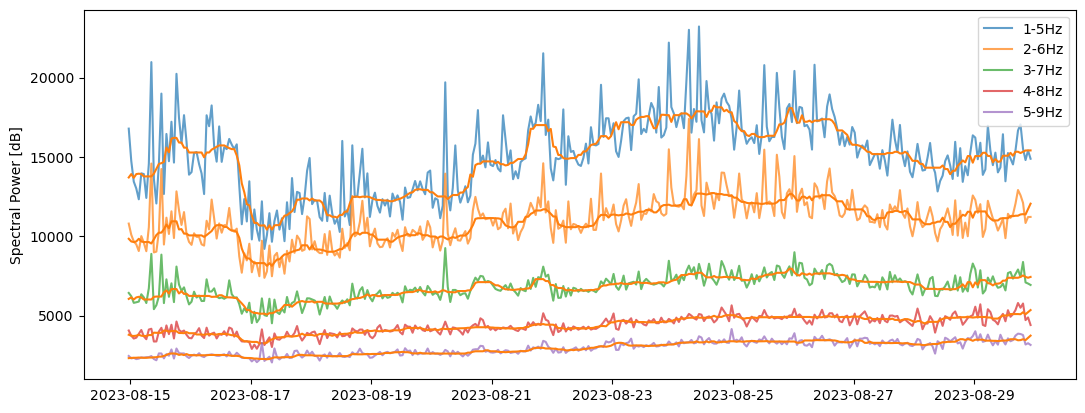

In [67]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6.4*2,4.8))
for freqmin, freqmax in [(1,5), (2,6), (3,7), (4,8), (5,9)]:
    idx_low = np.argmin(np.abs(freqs-freqmin))
    idx_high = np.argmin(np.abs(freqs-freqmax))
    Pxx_select = Pxx[idx_low:idx_high,:]
    Pxx_sum = np.sqrt(np.sum(Pxx_select, axis=0))
    Pxx_sum[np.isnan(Pxx_sum)] = 0

    ax.plot(t_bins, Pxx_sum, alpha=0.7, label='{}-{}Hz'.format(freqmin, freqmax))

    # pandas rolling
    df = pd.DataFrame(Pxx_sum)
    df = df.rolling(12, min_periods=0, center=True).median()
    roll = df.to_numpy()
    ax.plot(t_bins, roll, color='C1')

    ax.set_ylabel('Spectral Power [dB]')
    # ax.set_ylim(10,30)
plt.legend()

## Comparison with temperature

In [68]:
# read meteo station data
df_met = pd.read_csv('../data/meteo/meteo_bay_2022-24.csv') 
df_met['Time'] = pd.to_datetime(df_met['Time'])
df_met.set_index('Time', inplace=True)
df_met.head()

,RH,Temp [C],Solar [W/m^2],Precipitated [mm],Precipiteted [mm]
Time,,,,,
2022-07-23 13:20:00,0.372,12.8,9.2,2.4,NaN
2022-07-23 13:30:00,0.854,3.7,560.3,1.0,NaN
2022-07-23 14:00:00,0.855,4.1,701.3,0.0,NaN
2022-07-23 14:30:00,0.831,4.5,694.0,0.0,NaN
2022-07-23 15:00:00,0.820,5.1,761.7,0.0,NaN


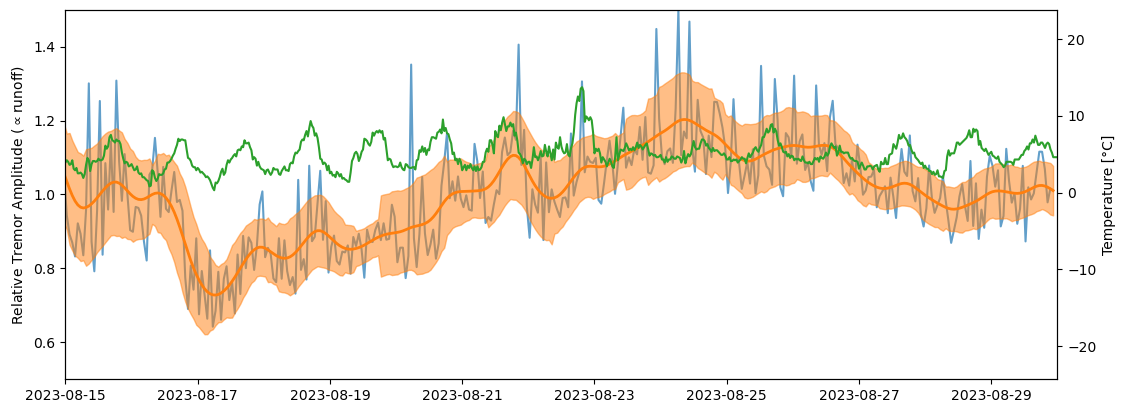

In [73]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6.4*2,4.8))
for freqmin, freqmax in [(1.5,10)]:#[(1,10), (3,10), (5,10), (7,10), (9,10)]:
    idx_low = np.argmin(np.abs(freqs-freqmin))
    idx_high = np.argmin(np.abs(freqs-freqmax))
    Pxx_select = Pxx[idx_low:idx_high,:]
    Pxx_sum = np.sqrt(np.sum(Pxx_select, axis=0))
    Pxx_sum[np.isnan(Pxx_sum)] = 0
    Pxx_sum = Pxx_sum/np.mean(Pxx_sum)

    ax.plot(t_bins, Pxx_sum, alpha=0.7, label='{}-{}Hz'.format(freqmin, freqmax))

    # interpolate data gaps, 0-pad and filter
    # pandas rolling
    df = pd.DataFrame(Pxx_sum)
    df_med = df.rolling(24, min_periods=0, center=True).median()
    df_std = df.rolling(24, min_periods=0, center=True).std()
    roll = df.to_numpy()
    sos = scipy.signal.butter(2, 1/12,'lowpass', fs=2, output='sos')
    filt = scipy.signal.sosfiltfilt(sos, Pxx_sum)
    ax.plot(t_bins, filt, color='C1', linewidth=2)
    ax.fill_between(t_bins, filt-df_std[0],
                    filt+df_std[0], color='C1', zorder=2, alpha=0.5)

    ax_t = ax.twinx()
    ax_t.plot(df_met.index, df_met['Temp [C]'], color='C2')
    ax_t.set_ylabel('Temperature [°C]')

    ax.set_ylabel(r'Relative Tremor Amplitude ($\propto$runoff)')
    ax.set_ylim(0.5,1.5)
    ax.set_xlim(datetime.datetime(2023,8,15),
                datetime.datetime(2023,8,30))

## Handle the calving events

In [95]:
t_start = UTCDateTime('2023-08-15')
t_end = UTCDateTime('2023-08-15T00:10')
# only read 1 station and 1 channel for now
st_read = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)

st = st_read.copy()
# now integrate and filter
# st.integrate() # found to work well for detecting calving evens
st.filter('bandpass', freqmin=1, freqmax=10) # typical band for calving events
st_read.merge()

1 Trace(s) in Stream:
XH.QJT03..HHZ | 2023-08-15T00:00:00.000000Z - 2023-08-15T00:10:00.000000Z | 200.0 Hz, 120001 samples

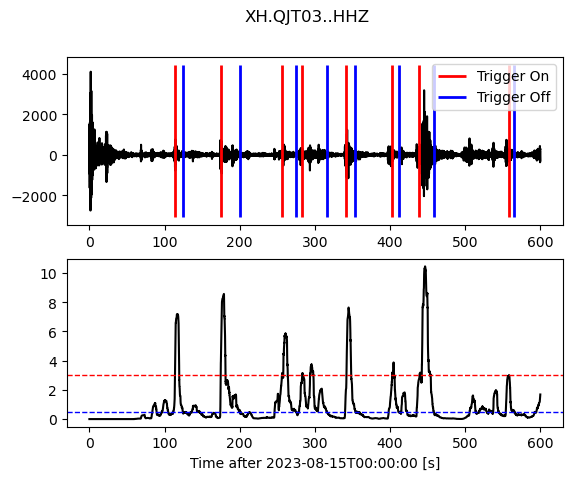

In [96]:
from obspy.signal.trigger import classic_sta_lta
from obspy.signal.trigger import plot_trigger
tr = st.select(component='Z')[0]

cft = classic_sta_lta(tr.data, int(5 * tr.stats.sampling_rate), int(60 * tr.stats.sampling_rate)) 
# sta_lta: short term and long term average
# if there's only noise (i.e. no calving events, nothing dramatic), sta / lta = 1
# otherwise it'll be relatively high; sta / lta > 1
# this method 
# Look at the spectrograms to see if there's a certain amount of power within a certain time
plot_trigger(tr, cft, 3, 0.5)